__Лабораторная работа №11__

Решите пожалуйста следующую задачу.

1. Используйте подход Нейронных Сетей (библиотека pytorch) и метод обратного распространения ошибки.

для данных находящихся по ссылке https://drive.google.com/file/d/1LBDnhITL0Wqwp5G6M6IBI-SSz8BIoNec/view?pli=1
    
выходящей меткой (учителем) является столбец / атрибут - outcome.

Данный датасет мы рассматривали на лекции с одним внутренним слоем.

Постройте топологию Нейронной Сети: 

- c 3 внутренними слоями (количество нейронов в сети пожалуйста подберите сами)

- c 4 внутренними слоями (количество нейронов в сети пожалуйста подберите сами)

Сравните значения метрики качества (accuracy) между указанными топологиями.



---

In [1]:
import numpy as np
from numpy import random as rng
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()
np.set_printoptions(precision=2)

# читаем данные

https://drive.google.com/file/d/1LBDnhITL0Wqwp5G6M6IBI-SSz8BIoNec/view?usp=sharing

In [2]:
url='https://drive.google.com/uc?id=1LBDnhITL0Wqwp5G6M6IBI-SSz8BIoNec'

In [3]:
df = pd.read_csv(url).convert_dtypes()
display(len(df))
display(df.info())
display(df.describe().T)
display(df.sample(3))

768

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    Int64  
 1   Glucose                   768 non-null    Int64  
 2   BloodPressure             768 non-null    Int64  
 3   SkinThickness             768 non-null    Int64  
 4   Insulin                   768 non-null    Int64  
 5   BMI                       768 non-null    Float64
 6   DiabetesPedigreeFunction  768 non-null    Float64
 7   Age                       768 non-null    Int64  
 8   Outcome                   768 non-null    Int64  
dtypes: Float64(2), Int64(7)
memory usage: 60.9 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.0,1.0,3.0,6.0,17.0
Glucose,768.0,120.894531,31.972618,0.0,99.0,117.0,140.25,199.0
BloodPressure,768.0,69.105469,19.355807,0.0,62.0,72.0,80.0,122.0
SkinThickness,768.0,20.536458,15.952218,0.0,0.0,23.0,32.0,99.0
Insulin,768.0,79.799479,115.244002,0.0,0.0,30.5,127.25,846.0
BMI,768.0,31.992578,7.88416,0.0,27.3,32.0,36.6,67.1
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.0,24.0,29.0,41.0,81.0
Outcome,768.0,0.348958,0.476951,0.0,0.0,0.0,1.0,1.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
140,3,128,78,0,0,21.1,0.268,55,0
101,1,151,60,0,0,26.1,0.179,22,0
155,7,152,88,44,0,50.0,0.337,36,1


In [4]:
df['Outcome'].unique() # список меток классов

<IntegerArray>
[1, 0]
Length: 2, dtype: Int64

----

In [5]:
# Pregnancies: Number of times pregnant
# Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
# BloodPressure: Diastolic blood pressure (mm Hg)
# SkinThickness: Triceps skin fold thickness (mm)
# Insulin: 2-Hour serum insulin (mu U/ml)
# BMI: Body mass index (weight in kg/(height in m)^2)
# DiabetesPedigreeFunction: Diabetes pedigree function
# Age: Age (years)
# Outcome: Class variable (0 or 1)

# формируем датасеты

In [6]:
def categorization(d,n_perc=5):
    perc = np.linspace(0.,1.,n_perc)
    bins = [ d.min()-1 ]+( d.describe(perc).iloc[4:].unique().tolist() )+[ d.max()+1 ]
    return pd.cut( d, bins=bins, include_lowest=True, labels=range(len(bins)-1) ).astype(int)

In [7]:
def binarization(d):
    return np.eye(d.max()+1,dtype=np.float32)[np.array(d,dtype=np.uint16)] 

In [8]:
cols = [
 'BMI',
 'BloodPressure',
 'DiabetesPedigreeFunction',
 'Glucose',
 'Insulin',
 'SkinThickness'
]

X = np.hstack([
        binarization( categorization(df['Age'],n_perc=3) ),
        binarization( categorization(df['Pregnancies'],n_perc=4) ),
#         binarization( categorization(df['BloodPressure'],n_perc=10) ),
#         binarization( categorization(df['Glucose'],n_perc=10) ),
#         binarization( categorization(df['DiabetesPedigreeFunction'],n_perc=10) ),
#         binarization( categorization(df['Insulin'],n_perc=10) ),
#         binarization( categorization(df['SkinThickness'],n_perc=10) ),
    
        np.array(df[cols],dtype=np.float32),
    ])

y = binarization(df['Outcome']) 

display( X.shape,y.shape )

(768, 14)

(768, 2)

## делим данные на учебные и тестовые

In [9]:
from sklearn.model_selection import train_test_split

X_train_, X_test_, y_train, y_test = train_test_split(X,y,test_size=.1)
X_train_, X_val_, y_train, y_val = train_test_split(X_train_,y_train,test_size=.1)
display( X_train_.shape, y_train.shape, X_test_.shape, y_test.shape, X_val_.shape, y_val.shape)

(621, 14)

(621, 2)

(77, 14)

(77, 2)

(70, 14)

(70, 2)

In [10]:
del X
del y

## нормируем значения (стандартизация)

In [11]:
X_train_[:,-len(cols):].shape

(621, 6)

In [12]:
X_train_[:,:-len(cols)].shape

(621, 8)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train_[:,-len(cols):])

X_train = np.hstack([
    X_train_[:,:-len(cols)],
    scaler.transform(X_train_[:,-len(cols):])
])

assert X_train.shape == X_train_.shape

X_test = np.hstack([
    X_test_[:,:-len(cols)],
    scaler.transform(X_test_[:,-len(cols):])
])
assert X_test.shape == X_test_.shape


X_val = np.hstack([
    X_val_[:,:-len(cols)],
    scaler.transform(X_val_[:,-len(cols):])
])
assert X_val.shape == X_val_.shape

display(X_train.shape,X_test.shape,X_val.shape)

(621, 14)

(77, 14)

(70, 14)

In [14]:
# до стандартизации
display( pd.DataFrame( X_train_[:,-len(cols):], columns=cols).describe().T )

,count,mean,std,min,25%,50%,75%,max
BMI,621.0,32.152657,7.865989,0.000,27.400,32.299999,36.799999,67.099998
BloodPressure,621.0,69.378426,18.842474,0.000,64.000,72.000000,80.000000,110.000000
DiabetesPedigreeFunction,621.0,0.472240,0.339768,0.078,0.241,0.368000,0.607000,2.420000
Glucose,621.0,121.516907,31.432083,0.000,100.000,118.000000,141.000000,199.000000
Insulin,621.0,81.381645,116.182434,0.000,0.000,36.000000,130.000000,846.000000
SkinThickness,621.0,20.623188,15.715404,0.000,0.000,23.000000,32.000000,63.000000


In [15]:
# после стандартизации
display( pd.DataFrame( X_train[:,-len(cols):], columns= cols).describe().T )
display( pd.DataFrame( X_test[:,-len(cols):], columns= cols).describe().T )

,count,mean,std,min,25%,50%,75%,max
BMI,621.0,9.982099e-09,1.000806,-4.090849,-0.604690,0.018747,0.591291,4.446423
BloodPressure,621.0,-1.535707e-09,1.000806,-3.684991,-0.285671,0.139243,0.564158,2.157589
DiabetesPedigreeFunction,621.0,-3.839268e-09,1.000806,-1.161256,-0.681131,-0.307045,0.396944,5.737240
Glucose,621.0,6.910684e-09,1.000806,-3.869131,-0.685104,-0.111979,0.620347,2.467083
Insulin,621.0,-9.214244e-09,1.000806,-0.701029,-0.701029,-0.390922,0.418803,6.586492
SkinThickness,621.0,9.214244e-09,1.000806,-1.313349,-1.313349,0.151363,0.724511,2.698688


,count,mean,std,min,25%,50%,75%,max
BMI,77.0,-0.110468,1.054636,-4.090849,-0.681030,-0.121208,0.527675,2.003567
BloodPressure,77.0,-0.052520,1.191610,-3.684991,-0.391900,0.033015,0.564158,2.794962
DiabetesPedigreeFunction,77.0,-0.011724,0.887478,-1.140638,-0.669348,-0.239297,0.529494,2.853539
Glucose,77.0,-0.028864,1.212432,-3.869131,-0.844306,-0.143820,0.811389,2.212361
Insulin,77.0,0.048173,1.165617,-0.701029,-0.701029,-0.563203,0.332662,4.286530
SkinThickness,77.0,-0.075250,1.040975,-1.313349,-1.313349,-0.103370,0.788194,1.807124


# строим модель классификатора

In [16]:
import torch
from torch import nn
#from torch import tanh
#from torch import sigmoid
from torch import relu
from torch import softmax

In [17]:
# три обрабатывающих слоя 

class MLP3(nn.Module): 
    
    def __init__(self,input_size,output_size):
        super().__init__()
        self.dense1 = nn.Linear(input_size,128) # первый - обрабатывающий  слой 
        self.dense2 = nn.Linear(128,128) # второй - обрабатывающий/скрытый слой
        self.dense3 = nn.Linear(128,output_size) # третий - обрабатывающий/выходной слой

    def forward(self,x):
        o = relu(self.dense1(x))
        o = relu(self.dense2(o))
        o = softmax(self.dense3(o),dim=1)
        return o
    
    def predict(self, x):    
        return self.forward(x)
    

In [18]:
# # четыре обрабатывающих слоя 

# class MLP4(nn.Module): 
    
#     def __init__(self,input_size,output_size):
#         super().__init__()
#         self.dense1 = nn.Linear(input_size,32) # первый - обрабатывающий  слой 
#         self.dense2 = nn.Linear(32,32) # второй - обрабатывающий/скрытый слой
#         self.dense3 = nn.Linear(32,16) # третий - обрабатывающий/скрытый слой
#         self.dense4 = nn.Linear(16,output_size) # четвёртый - обрабатывающий/выходной слой

#     def forward(self,x):
#         o = relu(self.dense1(x))
#         o = relu(self.dense2(o))
#         o = relu(self.dense3(o))
#         o = softmax(self.dense4(o),dim=1)
#         return o
    
#     def predict(self, x):    
#         return self.forward(x)
    

In [19]:
# model = MLP2( input_size=X_train.shape[1], output_size=y_train.shape[1], )
model = MLP3( input_size=X_train.shape[1], output_size=y_train.shape[1], )
# model = MLP4( input_size=X_train.shape[1], output_size=y_train.shape[1], )

# обучаем модель

In [20]:
from torch import optim

# criterion = nn.MSELoss() # ф-ция потери для выхода sigmoid
criterion = nn.CrossEntropyLoss() # ф-ция потери для выхода softmax
optimizer = optim.Adam( model.parameters(), lr=1e-5 ) # метод оптимизации ф-ции потери

In [21]:
from torch.utils.data import TensorDataset

# пакуем учебные данные в формат Torch
ds_train = TensorDataset( torch.Tensor(X_train), torch.Tensor(y_train) )

In [22]:
# используем GPU если есть
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda', index=0)

In [23]:
model = model.to(device)

In [24]:
from sklearn.metrics import accuracy_score

# будем мониторить погрешность модели по ходу обучения
def accuracy(x,y):
    with torch.set_grad_enabled(False):
        o = np.argmax( model.predict(torch.Tensor(x).to(device)).cpu().numpy(),axis=1 )
    return accuracy_score(y[:,1],o)

acc_train_history = [ accuracy(X_train,y_train) ] # начальное значение погрешности
acc_val_history = [ accuracy(X_val,y_val) ] # начальное значение погрешности

display( acc_train_history, acc_val_history,  )

[0.6876006441223832]

[0.7]

In [25]:
# считаем начальное значение ф-ции потери
with torch.set_grad_enabled(False):
    loss = criterion( 
            torch.Tensor(y_train).to(device), 
            model.predict( torch.Tensor(X_train).to(device) ) 
        ).cpu().numpy().flatten()[0]
    
loss_history = [ loss ] 
display( loss_history )

[0.80335945]

## основной цикл обучения

In [26]:
%%time


from torch.utils.data import DataLoader # генератор батчей

n_epoch = 1024*7 # количество эпох обучения
acc_min = .95 # порог допустимой погрешности модели

for i in tqdm(range(n_epoch)): 
    loss_batch = []
    for x,y in DataLoader(ds_train, 
                          batch_size=len(y_train)//4, 
                          shuffle=True): # получаем батч учебных примеров
        out = model.forward(x.to(device)) # считаем выход модели
        loss = criterion( y.to(device),out ) # вычисляем значение ф-ции потери
        loss_batch.append(loss.item()) # дополняем историю изменения значений ф-ции потери
        optimizer.zero_grad() # очищаем предыдущее значение градиента
        loss.backward()  # вычисляем текущее значение градиента ф-ции потери
        optimizer.step() # корректируем параметры модели
        
    loss_history.append(np.mean(loss_batch)) # дополняем историю изменения значений ф-ции потери
    acc_train_history.append( accuracy(X_train,y_train) ) #значение погрешности
    acc_val_history.append( accuracy(X_val,y_val) ) #значение погрешности
    
    if acc_val_history[-1] > acc_min: # проверяем достижение минимального порога погрешности модели
        print('step %i/%i: loss %.03f, acc threshold %.03f reached\n'%(i+1,n_epoch,loss_history[-1],acc_min))
        break
        
    if (i>n_epoch*0.25) : 
        if (acc_val_history[-25] > acc_val_history[-1]) : 
            print('step %i/%i: loss %.03f, val acc down \n'%(i+1,n_epoch,loss_history[-1]))
            break    

  0%|          | 0/7168 [00:00<?, ?it/s]

step 1794/7168: loss 0.611, val acc down 

CPU times: user 14.8 s, sys: 65.5 ms, total: 14.8 s
Wall time: 15.3 s


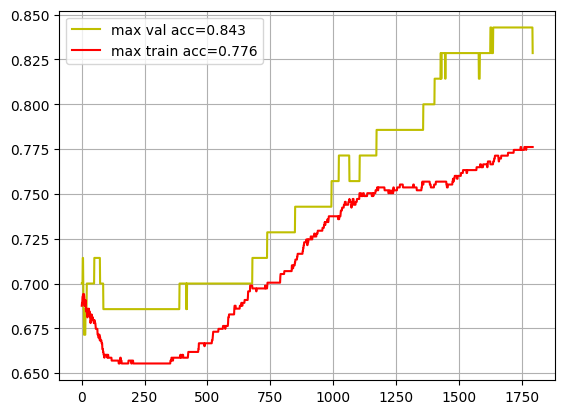

In [27]:
# история изменения значений погрешности модели
plt.plot(acc_val_history,label='max val acc=%.3f'%(max(acc_val_history)),c='y')
plt.plot(acc_train_history,label='max train acc=%.3f'%(max(acc_train_history)),c='r')
plt.grid()
plt.legend()

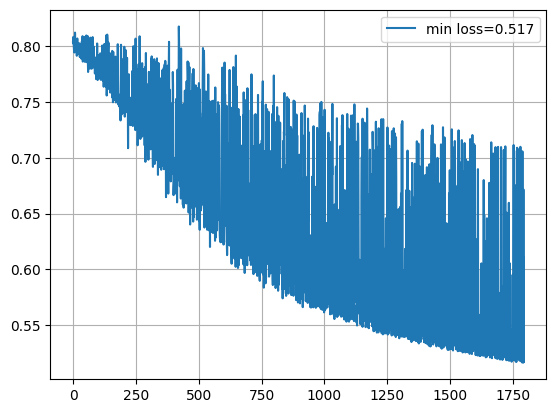

In [28]:
# история изменения значений ф-ции потери
plt.plot(loss_history,label='min loss=%.3f'%(min(loss_history)))
plt.grid()
plt.legend()

# тестируем модель

In [29]:
# предииктим метки для тестового датасета
with torch.set_grad_enabled(False):
    s = model.predict( torch.Tensor(X_test).to(device)).cpu().numpy()[:,1]
    
y_test_label = np.argmax(y_test,axis=1)

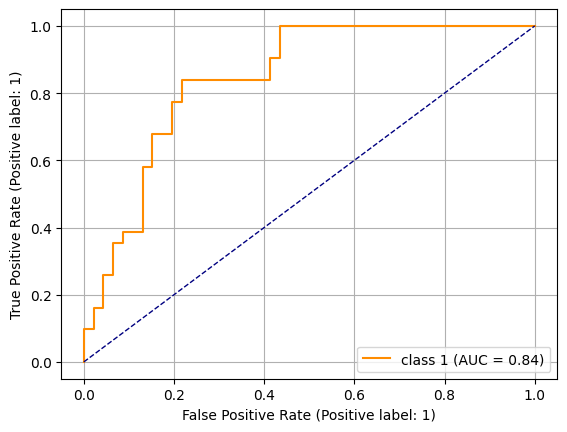

In [30]:
# рисуем ROC/AUC - зависимость точности и полноты при изменении порога скора
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions( y_test_label, s, name="class 1", color="darkorange", )
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.grid()

In [31]:
# определяем оптимальный порог скора 
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve( y_test_label, s )

#  максимальное количество True Positive при минимальном количестве False Positive
optimal_threshold = thresholds[ np.argmax( np.abs(tpr-fpr) )  ]
display(optimal_threshold)

0.10579526

In [32]:
# применяем оптимальный порог скора, предсказываем класс объектов
y_pred = (s>optimal_threshold).astype(int)

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        46
           1       0.71      0.81      0.76        31

    accuracy                           0.79        77
   macro avg       0.79      0.79      0.79        77
weighted avg       0.80      0.79      0.79        77



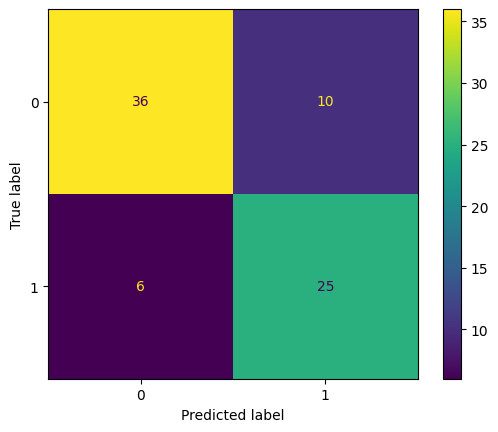

In [33]:
# оценка результатов тестирования

from sklearn.metrics import classification_report
print(classification_report(y_test_label,y_pred))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay( confusion_matrix=confusion_matrix(y_test_label, y_pred), ).plot()